## Forward CDT

Import necessary python packages

In [687]:
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
import jax
import functools
import math

## Tools

In [688]:


# Functional utilities
def IsSingle(v): return not isinstance(v, (list, tuple)) or hasattr(v, 'ndim') or isinstance(v, (str, dict))
def Broadcast(v,N): return [v]*N if IsSingle(v) else [*v]*N if len(v)==1 else v
def InvokeParams(func, params): 
    if (params is not None): return (
        func(params) if IsSingle(params) else
        func(*params[0],**params[1]) if (isinstance(params,tuple) and len(params)==2) else
        func(*[v for v in params if not isinstance(v,dict)],
            **next((kvp for kvp in params if isinstance(kvp,dict)), {})
        )
    )


def Accessor(data, i): return (
    None if (data is None) else 
    data if (IsSingle(data) or len(data)==0) else 
    data[i%len(data)] if (not isinstance(data, tuple)) else
    tuple(Accessor(item,i) for item in data)
)

def BuildSubplots(nrows,ncols, functionmap, figsize=(10, 10), col_firs=True):
    fig, ax = plt.subplots(nrows,ncols, figsize=figsize, layout="tight")
    for c in range(ncols):
        for r in range(nrows):
            axes = ax[c] if (nrows == 1) else ax[r] if (ncols == 1) else ax[r,c]
            i,j = (c,r) if (col_firs) else (r,c) 
            for func, params in functionmap.items():
                arg = Accessor(Accessor(params[0], i),j)
                kwargs = {key:Accessor(Accessor(val, i),j) for key,val in params[1].items()}
                if IsSingle(arg): arg = [arg]
                func(axes, *arg, **kwargs)
    plt.show()
    return fig, ax


### Signal tools

In [689]:
# --- 1. Signal Generation ---
def generate_random_gmm(key, N, num_components=3):
    """
    Generates a sum of random Gaussians.
    key: jax.random.PRNGKey
    N: number of points
    num_components: How many Gaussians to sum
    """
    # Split the key to generate different parameters
    k1, k2 = jax.random.split(key)
    
    # Generate random mus and sigmas
    mus = jax.random.uniform(k1, shape=(num_components,), minval=0.1, maxval=0.9)
    sigmas = jax.random.uniform(k2, shape=(num_components,), minval=0.02, maxval=0.08)
    
    # Generate the signal
    x = jnp.linspace(0, 1, N)
    # Broadcasting: (num_components, 1) - (1, N) -> (num_components, N)
    exponent = -((x[None, :] - mus[:, None])**2) / (2 * sigmas[:, None]**2)
    gaussians = jnp.exp(exponent)
    
    signal = gaussians.sum(axis=0)
    return (signal / jnp.sum(signal))

# Used to create gaussian distributions for the demo
def gaussian(x, mu, sigma):
    return 1/(sigma*np.sqrt(2*np.pi)) * np.exp(-((x-mu)**2)/(2*sigma**2))

def signal_gabor(t):
    w = 10
    tm = t[-1]/2
    s = np.real(math.pi**-0.25 * np.exp(4*math.pi*1j*w*(t-tm)) * np.exp(-120*((t-tm)**2)))
    return s

### Computation Tools

In [690]:


def jit_static(*args, **kwargs):
    """Jit a function, preserve types, and make it a staticmethod."""
    return staticmethod(jit_func)
def jit_func(*args, **kwargs):
    """Wrap a function with jit and optional args."""
    def wrapper(func): return functools.wraps(func)(jax.jit(func, *args, **kwargs))
    return wrapper





@jax.jit
def _trapcumsum(xsig, ysig):
    return jnp.cumulative_sum((0.5*(ysig[...,:-1]+ysig[...,1:])*jnp.diff(xsig, axis=-1)), axis=-1, include_initial=True)

@jax.jit
def _vmapinterp(x, xf,yf):
    return jnp.interp(x, xf, yf, left=yf[0], right=yf[-1])

@jax.jit
def _cdf(x,y):
    CDF = _trapcumsum(x,y)
    M = CDF[...,-1:]
    return jnp.where(M != 0, CDF/M, CDF)
    


@jax.jit
def _normalize(sig, scale=1):
    mass = jnp.sum(jnp.abs(sig), axis=-1, keepdims=True)
    return sig/mass * scale


def SplitSignal(signal):
    return (jnp.where(signal > 0, signal, 1e-9), jnp.where(signal < 0, -signal, 1e-9))

# Converts signals to strictly positive PDFs
def positivePDF(sig, epsilon=1e-7):
    temp = np.clip(np.abs(sig), epsilon, None)
    return temp/temp.sum()



### CDT Methods

In [691]:




@jax.jit
def CDT_Forward(x0,y0, x1,y1):
    CDF0, CDF1 = _trapcumsum(x0, y0), _trapcumsum(x1, y1)
    CDF0 /= CDF0[-1]
    CDF1 /= CDF1[-1]
    mapg = _vmapinterp(CDF1, CDF0, x0)
    return mapg, jnp.sum(y1, axis=-1, keepdims=True)

@jax.jit
def CDT_Inverse(x0,y0,map,mass):
    warped = _vmapinterp(map, x0, y0) * jnp.gradient(map, axis=-1)
    warped = warped / jnp.sum(warped, axis=-1, keepdims=True)
    return warped * mass



@jax.jit
def CDT_Forward0(x0,y0, x1,y1):
    CDF0, CDF1 = _trapcumsum(x0, y0), _trapcumsum(x1, y1)
    CDF0 /= CDF0[-1]
    CDF1 /= CDF1[-1]
    mapf = _vmapinterp(CDF0, CDF1, x1)
    return mapf, jnp.sum(y1, axis=-1, keepdims=True)

@jax.jit
def CDT_Inverse0(x0,y0,map,mass):
    J = jnp.gradient(map, x0, axis=-1)

    J = jnp.clip(jnp.abs(jnp.gradient(map, x0, axis=-1)), 1e-7)
    warped = _vmapinterp(x0, map, y0/J)
    return _normalize(warped, mass)


In [692]:
def CDT_Forward_Full(x0,y0, x1,y1):
    print(x0.shape, y0.shape, x1.shape, y1.shape)
    N = x1.shape[-1]
    # CDF has range of [0,1], same domains.
    cdf0 = _cdf(x0, y0)
    cdf1 = _cdf(x1, y1)
    t0 = jnp.linspace(0,1, x0.shape[-1])
    t1 = jnp.linspace(0,1, x1.shape[-1])
    MAPF = _vmapinterp(cdf0, cdf1, t1) # x1 = CDF1_inv(CDF0(x0)) or f_fwd
    MAPG = _vmapinterp(cdf1, cdf0, t0) # x0 = CDF0_inv(CDF1(x1)) or f_inv
    MASS = jnp.sum(y1, axis=-1, keepdims=True)
    return (MAPF, MAPG), (MASS, N)

def CDT_Inverse_Full(x0,y0, maps,meta):
    
    x1 = jnp.linspace(0,1, maps[0].shape[-1])
    JF = jnp.clip(jnp.gradient(maps[0], x0, axis=-1), 1e-7)
    warpedf = _vmapinterp(x1, maps[0], y0/JF)
    warpedf /= jnp.sum(warpedf, axis=-1, keepdims=True)


    JG = jnp.clip(jnp.gradient(maps[1], x1, axis=-1), 1e-7)
    warpedg = _vmapinterp(maps[1], x0, y0) * JG
    warpedg /= jnp.sum(warpedg, axis=-1, keepdims=True)

    
    return warpedf*meta[0], warpedg*meta[0]



In [693]:
def CDT_Forward_Full(x0,y0, x1,y1):
    cdf0 = _cdf(x0, y0)
    cdf1 = _cdf(x1, y1)
    MAPF = _vmapinterp(cdf0, cdf1, x1) # x1 = CDF1_inv(CDF0(x0)) or f_fwd
    MAPG = _vmapinterp(cdf1, cdf0, x0) # x0 = CDF0_inv(CDF1(x1)) or f_inv
    MASS = jnp.sum(y1, axis=-1, keepdims=True)
    return (MAPF, MAPG), (MASS, MASS)

def CDT_Inverse_Full(x0,y0, maps,meta):
    
    x1 = jnp.linspace(jnp.min(maps[0]), jnp.max(maps[0]), maps[0].shape[-1])
    JF = jnp.clip(jnp.gradient(maps[0], x1, axis=-1), 1e-7)
    warpedf = _vmapinterp(x1, maps[0], y0/JF)
    warpedf /= jnp.sum(warpedf, axis=-1, keepdims=True)


    JG = jnp.clip(jnp.gradient(maps[1], x1, axis=-1), 1e-7)
    warpedg = _vmapinterp(maps[1], x0, y0) * JG
    warpedg /= jnp.sum(warpedg, axis=-1, keepdims=True)

    
    return warpedf*meta[0], warpedg*meta[0]

def CDT_Inverse_Full_New(x0,y0, maps,meta):
    
    x1 = jnp.linspace(jnp.min(maps[0]), jnp.max(maps[0]), maps[0].shape[-1])
    InvMap = _vmapinterp(x1, maps[0], x0)
    JF = jnp.clip(jnp.gradient(InvMap, x0, axis=-1), 1e-9)
    warpedf = _vmapinterp(InvMap, x0, y0) * JF
    warpedf /= jnp.sum(warpedf, axis=-1, keepdims=True)



    JG = jnp.clip(jnp.gradient(maps[1], x1, axis=-1), 1e-7)
    warpedg = _vmapinterp(maps[1], x0, y0) * JG
    warpedg /= jnp.sum(warpedg, axis=-1, keepdims=True)

    
    return warpedf*meta[0], warpedg*meta[0]


def CDT_Transform_Full(x0,y0, x1,y1):
    cdf0 = _cdf(x0, y0)
    cdf1 = _cdf(x1, y1)
    MAPF = _vmapinterp(cdf0, cdf1, x1)
    MAPG = _vmapinterp(cdf1, cdf0, x0)
    MASS = jnp.sum(y1, axis=-1, keepdims=True)
    JF = jnp.clip(jnp.gradient(MAPF, x0, axis=-1), 1e-7)
    JG = jnp.clip(jnp.gradient(MAPG, x1, axis=-1), 1e-7)

    x1 = jnp.linspace(jnp.min(MAPF), jnp.max(MAPF), MAPF.shape[-1])
    InvMap = _vmapinterp(x1, MAPF, x0)
    warpedf = _vmapinterp(InvMap, x0, y0) * JG
    warpedf /= jnp.sum(warpedf, axis=-1, keepdims=True)
    
    warpedg = _vmapinterp(MAPG, x0, y0) * JG
    warpedg /= jnp.sum(warpedg, axis=-1, keepdims=True)

    return (MAPF,MAPG), (JF,JG), (warpedf*MASS, warpedg*MASS), MASS


## Testing

### 1D Testing

First test uniform signal vs gaussian.

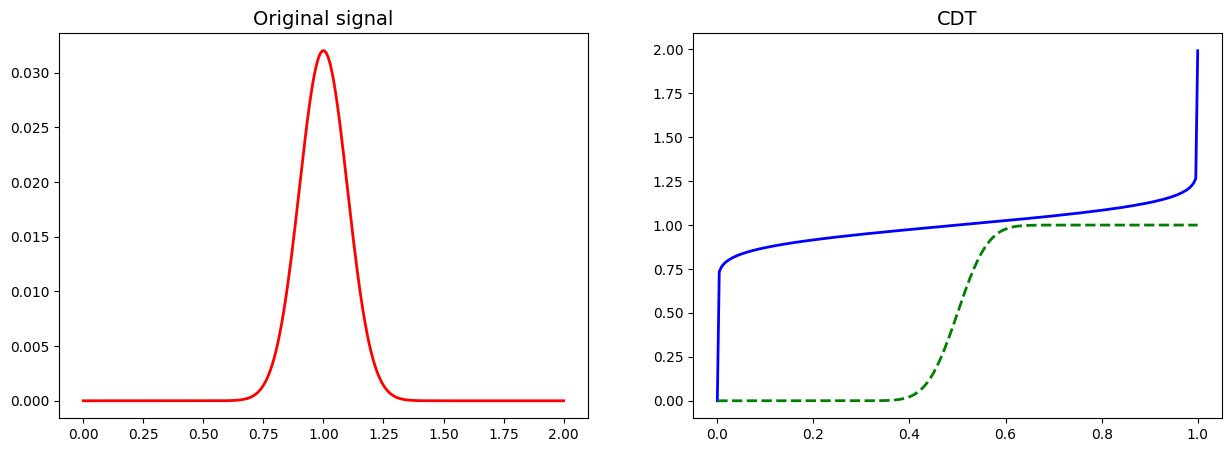

In [694]:
N=250
x0 = np.linspace(0, 1, N)
I0= np.ones(x0.size)
x=np.linspace(0, 2, N)
mu=x[len(x)-1]/2.
sigma=0.1
I1=1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))

#Convert signals to strictly positive PDFs:
epsilon = 1e-7
I0 = abs(I0) + epsilon
I0 = I0/I0.sum()
I1 = abs(I1) + epsilon
I1 = I1/I1.sum()

STATE = CDT_Forward_Full(x0,I0, x,I1)
MAPS, MASS = STATE
xtilde = x0



# Plot I1 and I1_hat
fontSize=14
fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,5))
ax[0].plot(x, I1, 'r-', linewidth=2)
ax[0].set_title('Original signal',fontsize=fontSize)

ax[1].plot(x0, MAPS[0], 'b-',linewidth=2)
ax[1].plot(x0, MAPS[1], 'g--',linewidth=2)
# ax[1].plot(x0, InvMap, 'r--',linewidth=2)
ax[1].set_title('CDT',fontsize=fontSize)
plt.show()

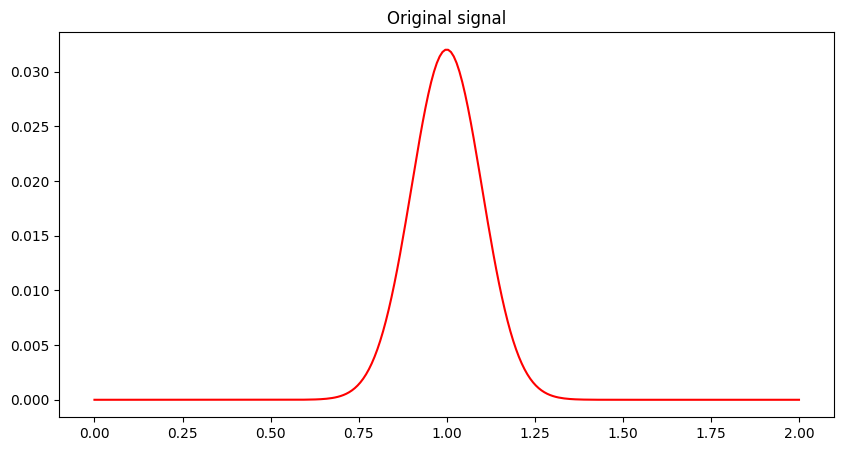

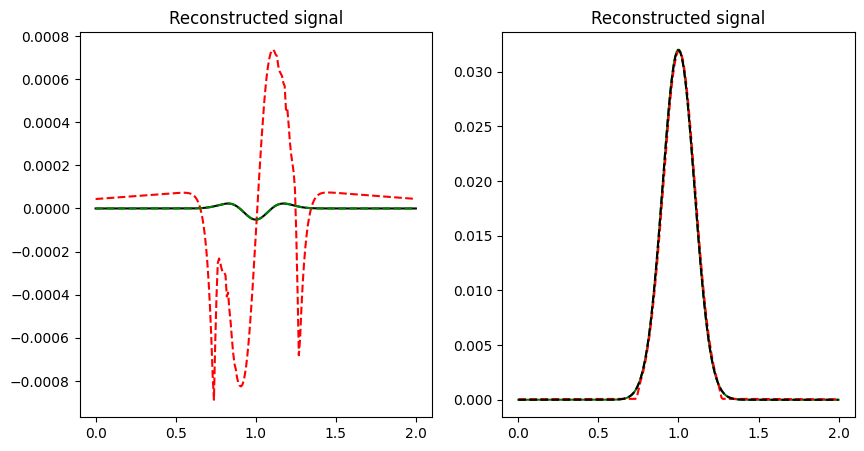

In [695]:
I1_recon = CDT_Inverse_Full(x0, I0, MAPS, MASS)
I1_recon2 = CDT_Inverse_Full_New(x0, I0, MAPS, MASS)
_, _, I1_recon2, _ = CDT_Transform_Full(x0,I0, x,I1)


fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,5))
ax.plot(x,I1, 'r-')
ax.set_title('Original signal')
plt.show()


# Plot I1 and I1_recon
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False, figsize=(10,5))

# ax[0].plot(x,I1_recon[0], 'b-')
# ax[0].plot(x,I1_recon2[0], 'k--')
ax[0].plot(x,I1_recon2[0]-I1, 'k-')
ax[0].plot(x,I1_recon[0]-I1, 'r--')
ax[0].plot(x,I1_recon[1]-I1, 'g--')
ax[0].set_title('Reconstructed signal')

ax[1].plot(x,I1, 'g')
ax[1].plot(x,I1_recon[0], 'r--')
ax[1].plot(x,I1_recon2[0], 'k--')
ax[1].set_title('Reconstructed signal')
plt.show()

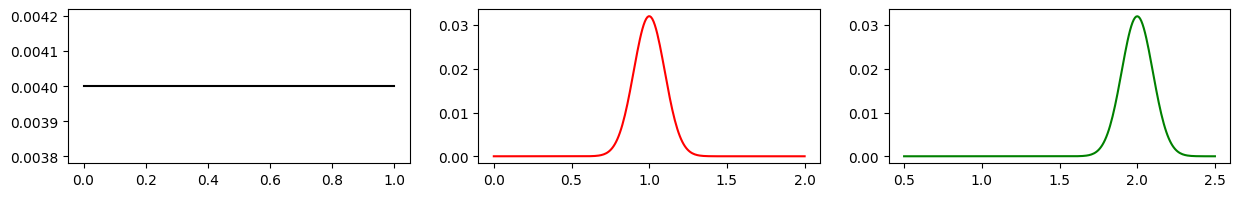

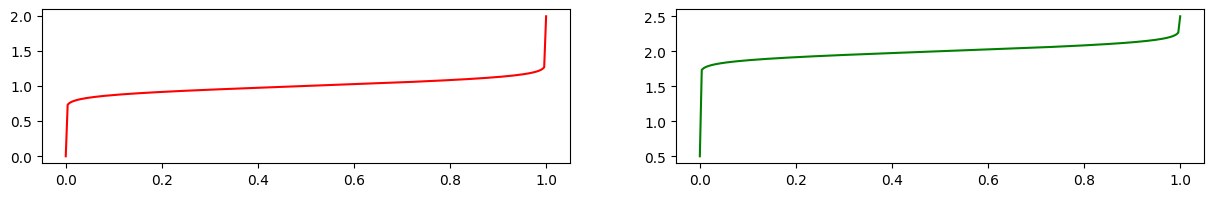

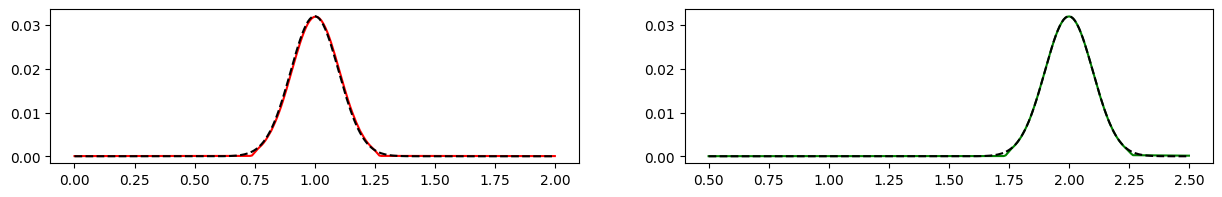

In [696]:
N=250
tau = 0.5

x0 = np.linspace(0, 1, N)
I0 = np.ones(x0.size)

x1 = np.linspace(0, 2, N)
I1 = gaussian(x1, mu=x1[0] + (x1[-1]-x1[0])/2, sigma=0.1)

x2 = x1+tau
I2 = np.interp(x-tau, x, I1)


#Convert signals to strictly positive PDFs:
I0 = positivePDF(I0)
I1 = positivePDF(I1)
I2 = positivePDF(I2)

STATE1 = CDT_Forward_Full(x0,I0, x1,I1)
MAPS1, MASS1 = STATE1
RECON1 = CDT_Inverse_Full(x0,I0, MAPS1, MASS1)

STATE2 = CDT_Forward_Full(x0,I0, x2,I2)
MAPS2, MASS2 = STATE2
RECON2 = CDT_Inverse_Full(x0,I0, MAPS2, MASS2)

#Plot the signals and CDTs
fig, ax = plt.subplots(1, 3, sharex=False, sharey=False, figsize=(15,2))
ax[0].plot(x0, I0, 'k-')
ax[1].plot(x1, I1, 'r-')
ax[2].plot(x2, I2, 'g-')
plt.show()

fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,2))
ax[0].plot(x0, MAPS1[0], 'r-')
ax[1].plot(x0, MAPS2[0], 'g-')
plt.show()

fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,2))
ax[0].plot(x1, RECON1[0], 'r-')
ax[0].plot(x1, I1, 'k--')
ax[1].plot(x2, RECON2[0], 'g-')
ax[1].plot(x2, I2, 'k--')
plt.show()

### Other

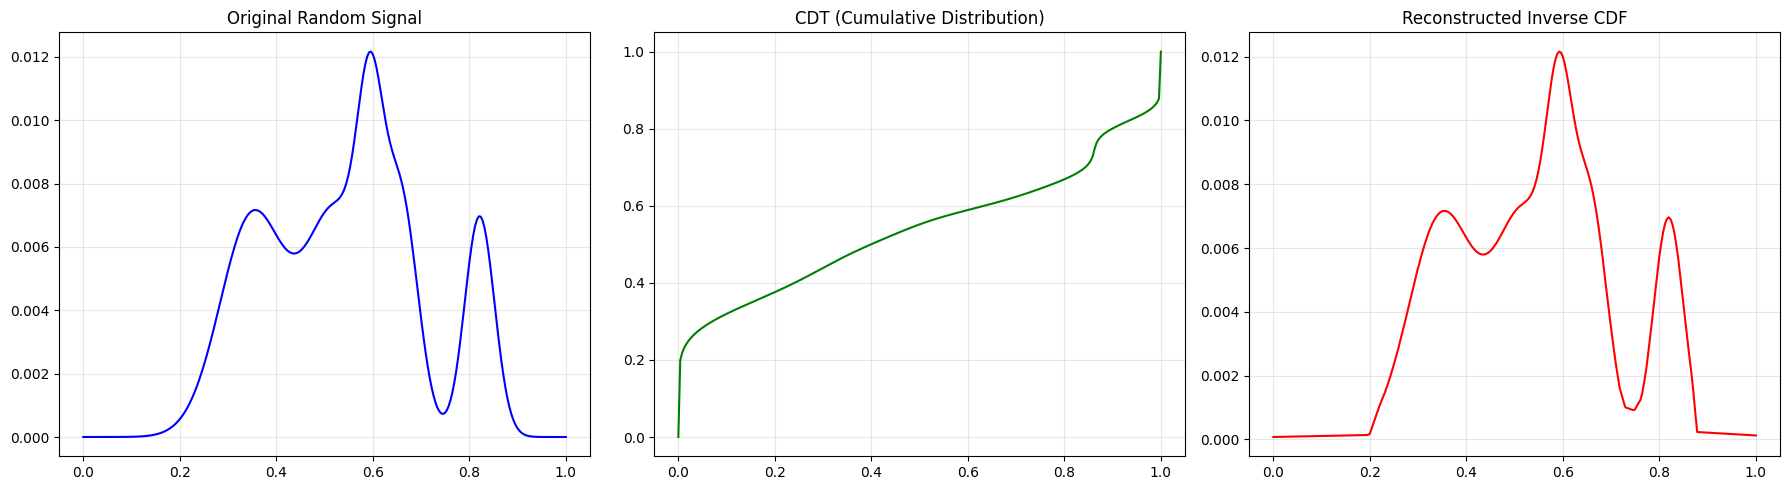

(<Figure size 1800x500 with 3 Axes>,
 array([<Axes: title={'center': 'Original Random Signal'}>,
        <Axes: title={'center': 'CDT (Cumulative Distribution)'}>,
        <Axes: title={'center': 'Reconstructed Inverse CDF'}>],
       dtype=object))

In [697]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from pytranskit.optrans.continuous import CDT as CDTold


# --- 3. Execution ---
N = 256
batch_size = 100


xref = jnp.linspace(0.0, 2.0, 256) #* 4.5
yref = (jnp.zeros(256) + 0.1) #* 8
yref.at[0].set(1)

xsig = jnp.linspace(0, 1, N) #/ 2
ysig = generate_random_gmm(jax.random.PRNGKey(42), N, 5) #* 3


cdtold = CDTold()
transformed_signal_old = cdtold.forward(xref, yref, xsig, ysig)[0]
reconstructed_signal_old = cdtold.inverse(transformed_signal_old, yref, xsig)






BuildSubplots(1, 3, figsize=(18,5), col_firs=True, functionmap= {
        plt.Axes.grid: ([True], {'alpha':0.3}),
        plt.Axes.set_title: ([
            "Original Random Signal",
            "CDT (Cumulative Distribution)",
            "Reconstructed Inverse CDF"
        ], {}
        ),
        plt.Axes.plot: ([
            (xsig, ysig),
            (xsig, transformed_signal_old),
            (xsig, reconstructed_signal_old)
        ], {'color':['blue', 'green', 'red']})
    }              
)



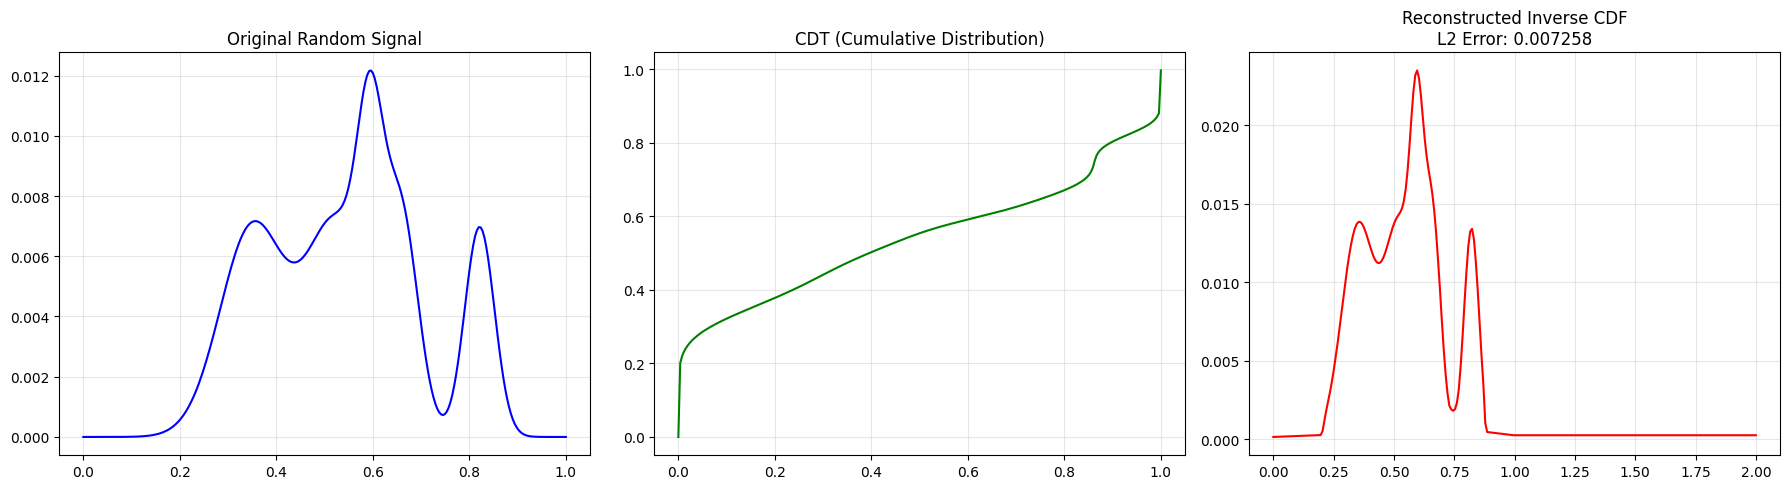

<Figure size 640x480 with 0 Axes>

In [698]:




transformed_signal, mass1 = CDT_Forward(xref, yref, xsig, ysig)
transformed_signal2, mass2 = CDT_Forward0(xref, yref, xsig, ysig)
reconstructed_signal = CDT_Inverse(xref, yref, transformed_signal, mass1)
reconstructed_signal2 = CDT_Inverse0(xref, yref, transformed_signal2, mass2)


# Calculate L2 Error
error = jnp.sqrt(jnp.mean((ysig - reconstructed_signal2)**2))



BuildSubplots(1, 3, figsize=(18,5), col_firs=True, functionmap= {
        plt.Axes.grid: ([True], {'alpha':0.3}),
        plt.Axes.set_title: ([
            "Original Random Signal",
            "CDT (Cumulative Distribution)",
            f"Reconstructed Inverse CDF\nL2 Error: {error:.6f}"
        ], {}
        ),
        plt.Axes.plot: ([
            (xsig, ysig),
            (xsig, [transformed_signal2, transformed_signal2]),
            (xref, [reconstructed_signal2, reconstructed_signal2])
        ], {'color':['blue', 'green', 'red']})
    }              
)

plt.tight_layout()
plt.show()

In [699]:
import math
N = 300

## Gaussian distribution
t0 = np.linspace(0,1,N) # Domain of the reference
#s0 = np.exp(-10*(t0-0.5)**2)/np.sqrt(2*np.pi)
s0 = np.ones(N)
s0 = s0/s0.sum()

t = np.linspace(0,0.5,N) # Domain of the input signal


s = signal_gabor(t)
s_CDF = np.cumsum(s)






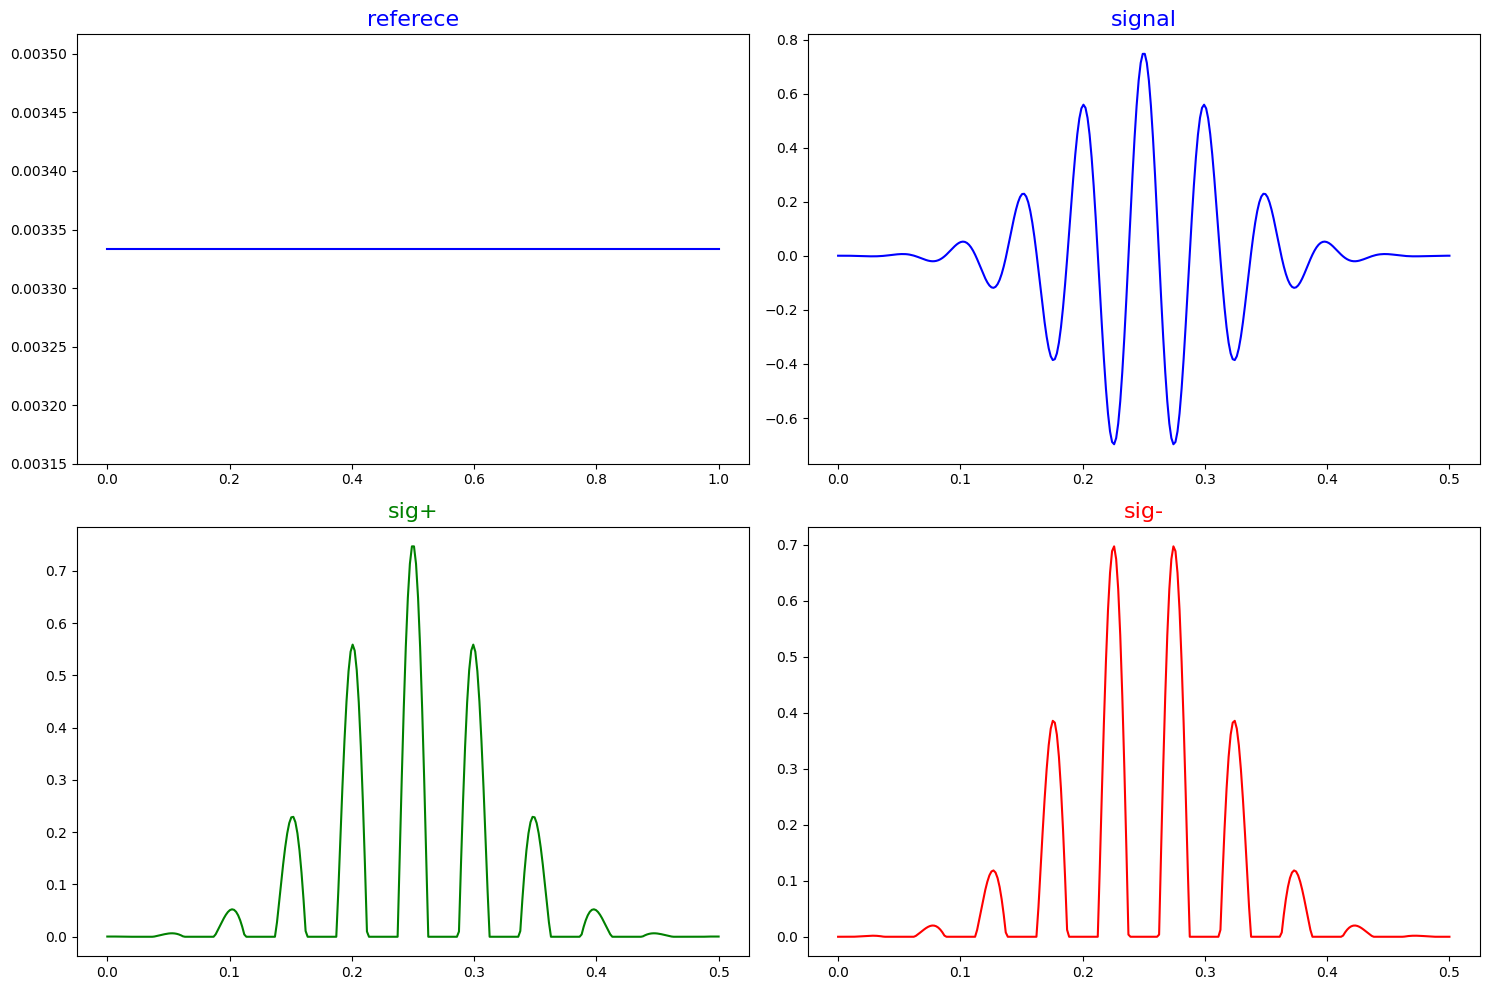

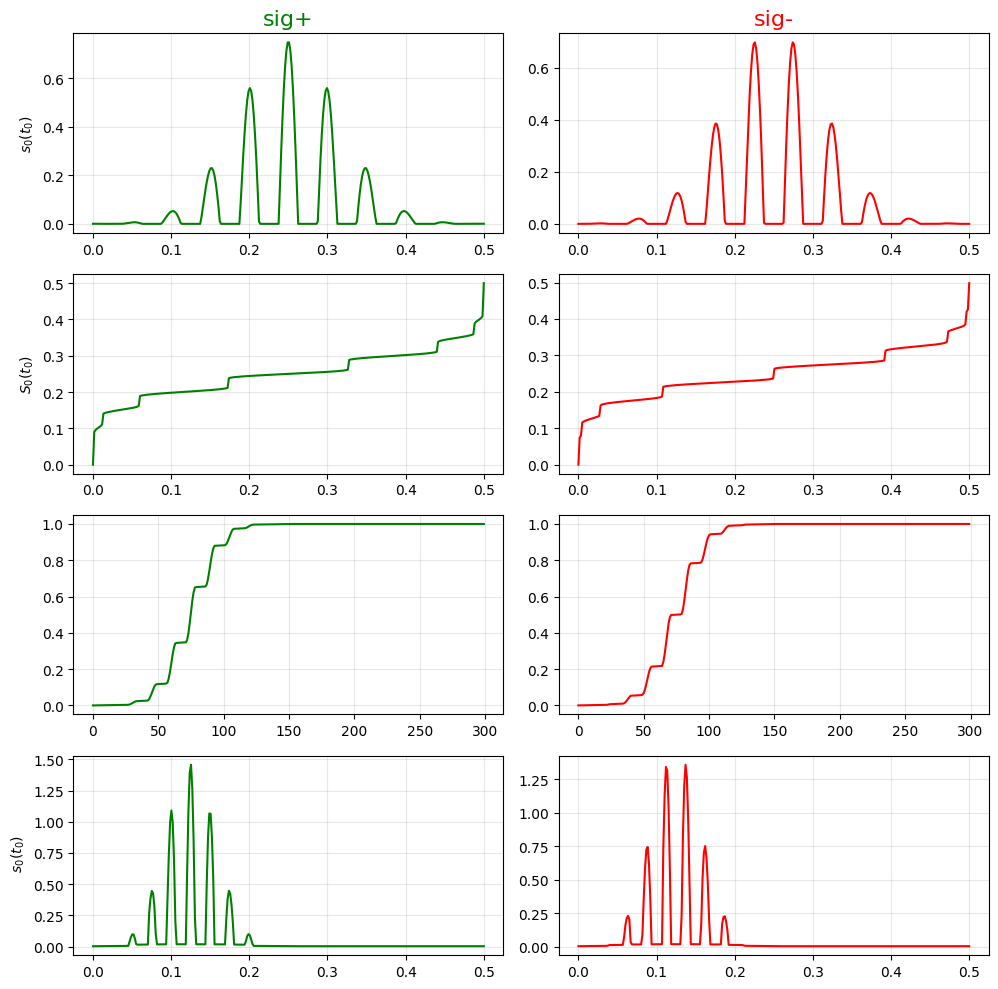

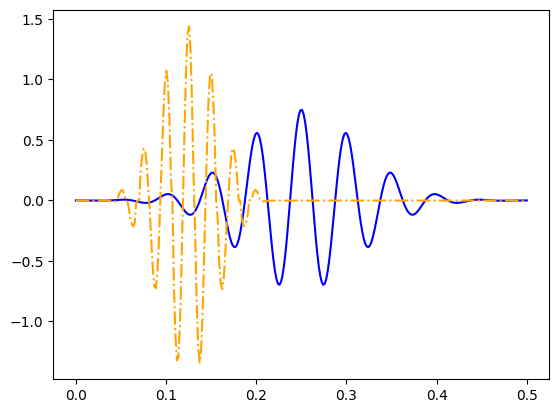

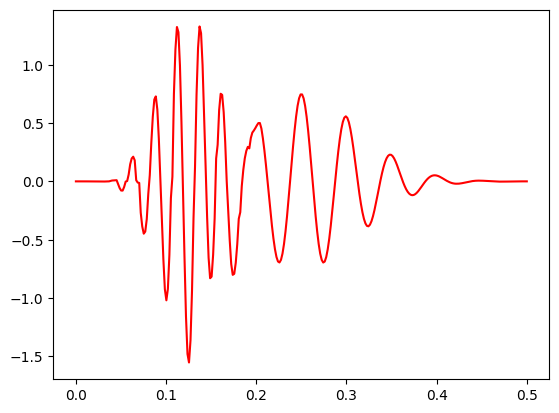

In [700]:


ysigpos, ysigneg = SplitSignal(s)

pshat, pmhat = CDT_Forward0(t0, s0, t, ysigpos)
nshat, nmhat = CDT_Forward0(t0, s0, t, ysigneg)

pshat_inv = jnp.interp(jnp.linspace(0,1, pshat.shape[-1]), pshat, t)
pshat_inv /= pshat_inv[-1]
nshat_inv = jnp.interp(jnp.linspace(0,1, nshat.shape[-1]), nshat, t)
nshat_inv /= nshat_inv[-1]


psrecon = CDT_Inverse0(t0,s0, pshat, pmhat)
nsrecon = CDT_Inverse0(t0,s0, nshat, nmhat)





BuildSubplots(2, 2, figsize=(15,10), col_firs=False, functionmap= {
        plt.Axes.grid: ([False], {}),
        plt.Axes.set_title: (
            [["referece", "signal"],["sig+", "sig-"]], 
            {'fontsize':16, 'color':[['blue','blue'],['green','red']]}
        ),
        plt.Axes.plot: ([
            [(t0, s0), (t, s)],
            [(t, ysigpos), (t, ysigneg)]
        ], {'color':[['blue', 'blue'], ['green', 'red']]})
    }              
)


BuildSubplots(4,2, col_firs=True, functionmap={
    plt.Axes.grid: (
        [True], 
        {"alpha":0.3}
    ), 
    plt.Axes.set_title: ([
        ["sig+",None,None,None], 
        ["sig-",None,None,None]], 
        {'color':['green','red'], 'fontsize':16}
    ),
    plt.Axes.set_ylabel: ([
        ["$s_0(t_0)$", "$S_0(t_0)$", None, "$~s_0(t_0)$"], 
        [None, None, None, None]], 
        {}
    ),
    plt.Axes.plot: ([
        [(t, ysigpos), (t, pshat), (pshat_inv,), (t, psrecon)],
        [(t, ysigneg), (t, nshat), (nshat_inv,), (t, nsrecon)]], 
        {'color': ['green', 'red'] }
    )
})


plt.show()

# sigrecon = psrecon - nsrecon

plt.plot(t, s, color='blue')
plt.plot(t, psrecon - nsrecon, color='orange', linestyle='dashdot')
plt.show()

plt.plot(t, s - (psrecon - nsrecon), color='red')
plt.show()
# plt.plot(t, s-sigrecon)

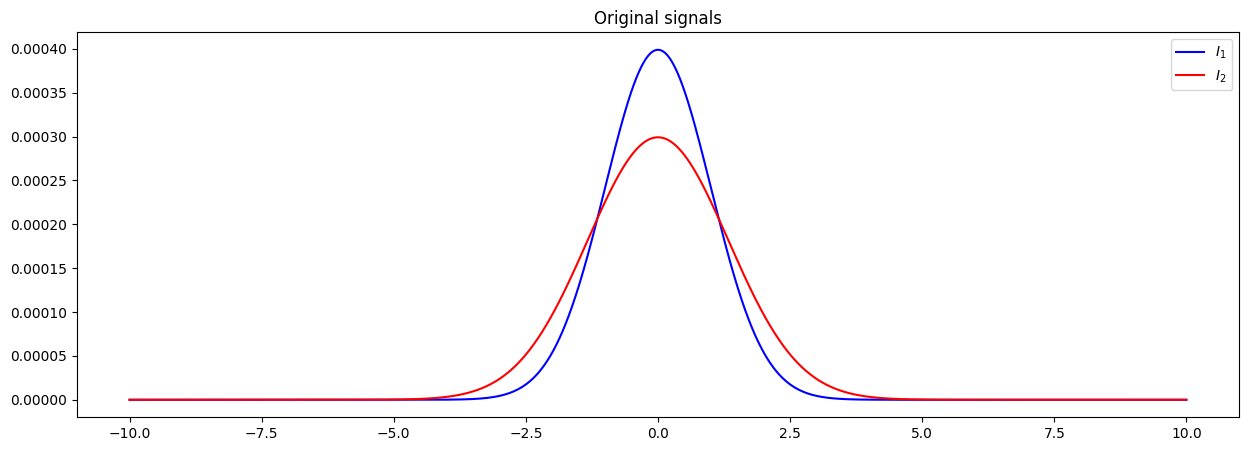

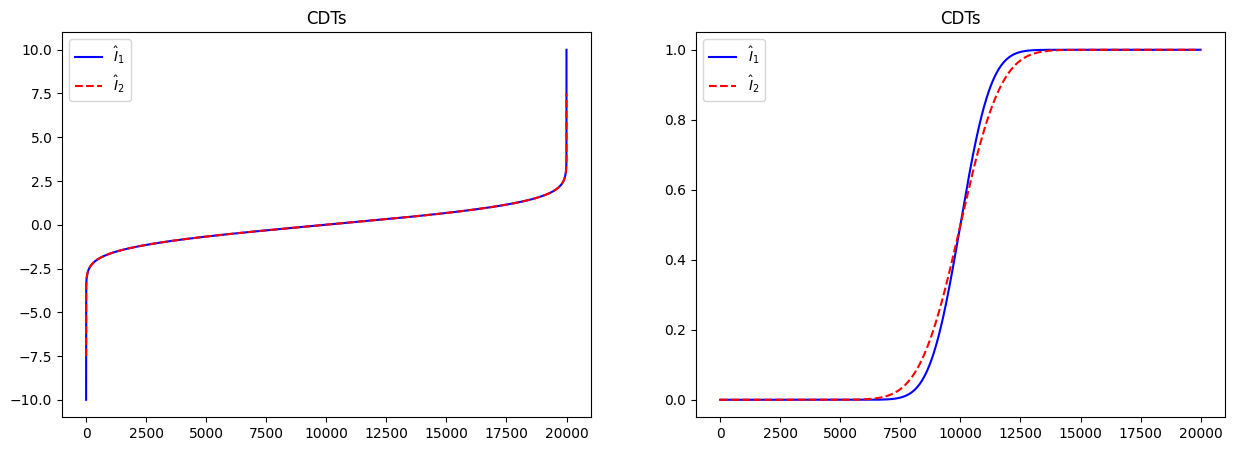

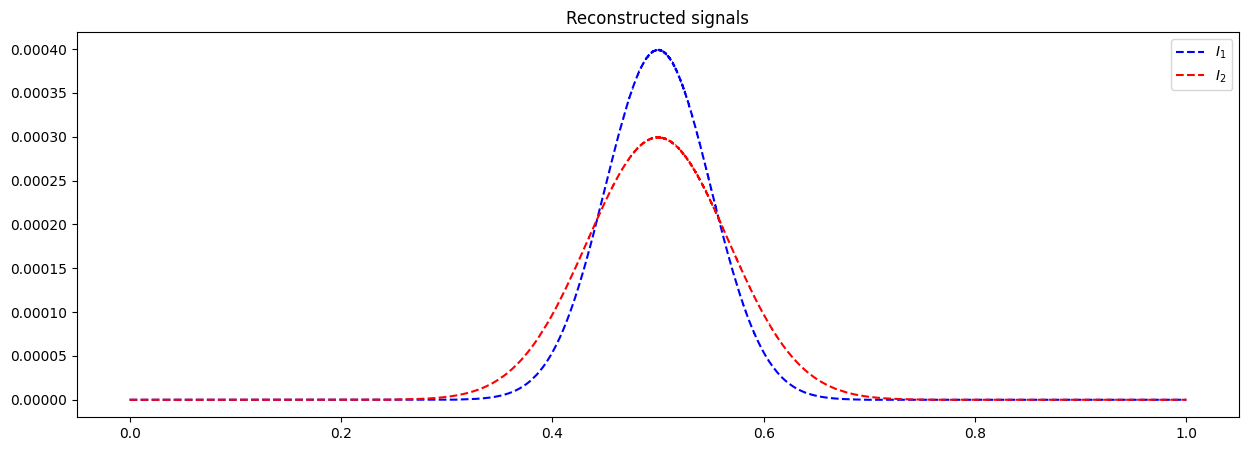

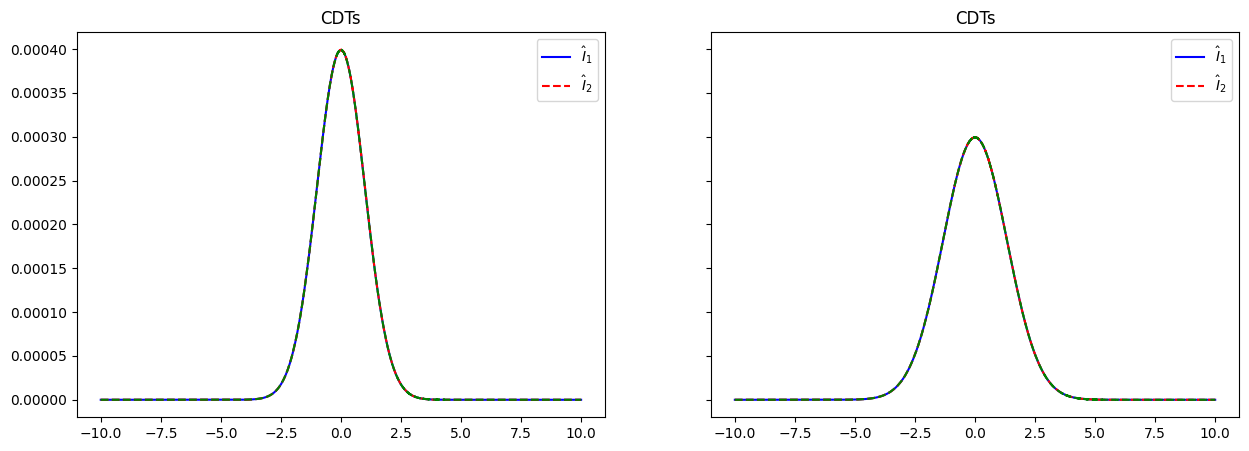

In [701]:
from scipy.stats import norm
epsilon = 1e-7
x = np.arange(-10,10,0.001)

N=len(x)

x0 = np.linspace(0, 1, round(N))
I0= np.ones(x0.size)

I1 = norm.pdf(x,0,1)
# create a scaled version of I1; i.e. I2(t) = I1(alpha*t)
alpha = 0.75
I2 = np.interp(alpha*x, x, I1)

# Convert signals to strictly positive PDFs
I0 = abs(I0) + epsilon
I0 = I0/I0.sum()
I1 = abs(I1) + epsilon
I1 = I1/I1.sum()
I2 = abs(I2) + epsilon
I2 = I2/I2.sum()


MAPS1, META1 = CDT_Forward_Full(x0,I0, x,I1)
MAPS2, META2 = CDT_Forward_Full(x0,I0, x*alpha,I2)
I1_hat0, I1_hat1 = MAPS1
I2_hat0, I2_hat1 = MAPS2
RECONS1 = CDT_Inverse_Full(x0,I0, MAPS1, META1)
RECONS2 = CDT_Inverse_Full(x0,I0, MAPS2, META2)


#Plot the signals and CDTs
fig, ax = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(15,5))
ax.plot(x, I1, 'b-')
ax.plot(x, I2, 'r-')
ax.set_title('Original signals')
ax.legend([r'$I_1$',r'$I_2$'])


fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,5))
ax[0].plot(I1_hat0, 'b-')
ax[0].plot(I2_hat0, 'r--')
ax[0].set_title('CDTs')
ax[0].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

ax[1].plot(I1_hat1, 'b-')
ax[1].plot(I2_hat1, 'r--')
ax[1].set_title('CDTs')
ax[1].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

#Plot the signals and CDTs
fig, ax = plt.subplots(1, 1, sharex=False, sharey=False, figsize=(15,5))
ax.plot(x0, RECONS1[0], 'b--')
ax.plot(x0, RECONS2[0], 'r--')
ax.set_title('Reconstructed signals')
ax.legend([r'$I_1$',r'$I_2$'])



fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(15,5))
ax[0].plot(x, I1, 'b-')
ax[0].plot(x, RECONS1[0], 'r--')
ax[0].plot(x, RECONS1[1], 'g--')
ax[0].set_title('CDTs')
ax[0].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])

ax[1].plot(x, I2, 'b-')
ax[1].plot(x, RECONS2[0], 'r--')
ax[1].plot(x, RECONS2[1], 'g--')
ax[1].set_title('CDTs')
ax[1].legend([r'$\hat{I}_1$',r'$\hat{I}_2$'])
plt.show()

In [702]:
N=250
x0 = np.linspace(0, 1, N)
I0= np.ones(x0.size)
x=np.linspace(0, 2, N)
mu=x[len(x)-1]/2.
sigma=0.1
I1=1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))
I0=1/(sigma*np.sqrt(2*np.pi))*np.exp(-((x-mu)**2)/(2*sigma**2))

#Convert signals to strictly positive PDFs:
epsilon = 1e-7
I0 = abs(I0) + epsilon
I0 = I0/I0.sum()
I1 = abs(I1) + epsilon
I1 = I1/I1.sum()


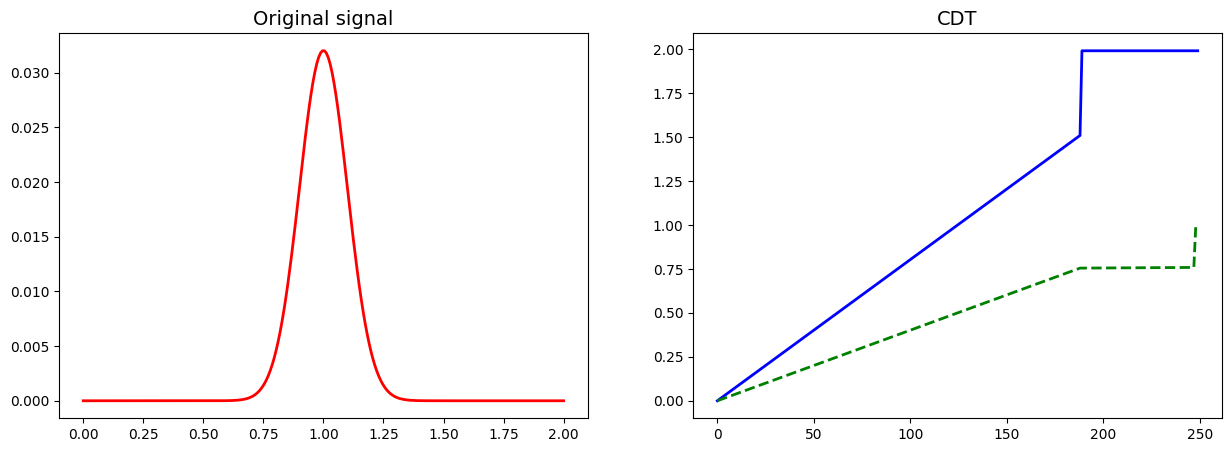

In [703]:
# The transport map and the mass to preserve
STATE = CDT_Forward_Full(x0,I0, x,I1)
MAPS, MASS = STATE
xtilde = x0

InvMap = jnp.interp(x0, MAPS[1], x0)


# Plot I1 and I1_hat
fontSize=14
fig, ax = plt.subplots(1, 2, sharex=False, sharey=False, figsize=(15,5))
ax[0].plot(x, I1, 'r-', linewidth=2)
ax[0].set_title('Original signal',fontsize=fontSize)

ax[1].plot(MAPS[0], 'b-',linewidth=2)
ax[1].plot(InvMap, 'g--',linewidth=2)
ax[1].set_title('CDT',fontsize=fontSize)
plt.show()

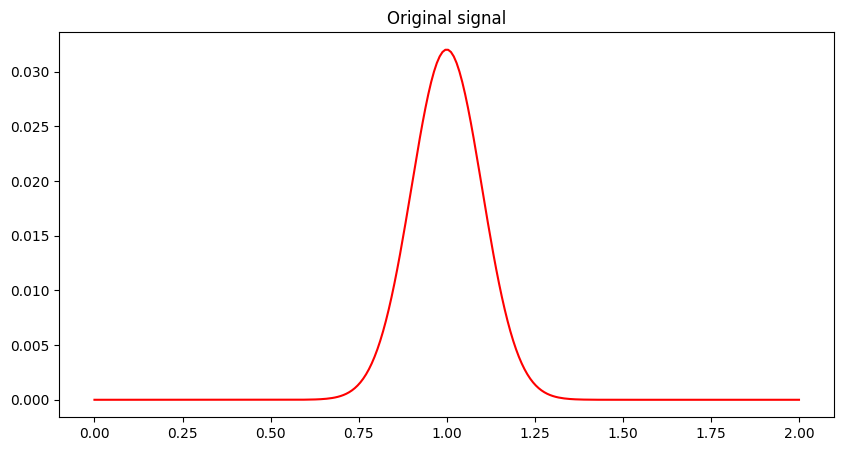

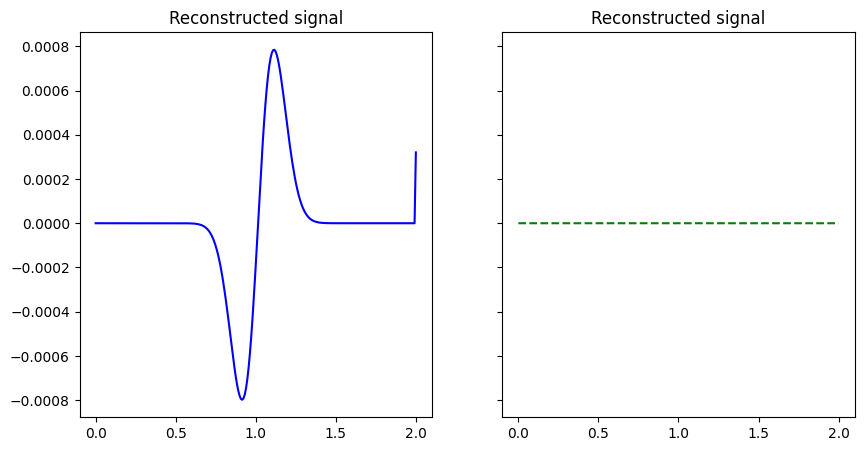

In [704]:
I1_recon = CDT_Inverse_Full(x0, I0, MAPS, MASS)



fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(10,5))
ax.plot(x,I1, 'r-')
ax.set_title('Original signal')
plt.show()


# Plot I1 and I1_recon
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10,5))

ax[0].plot(x,I1_recon[0]-I1, 'b-')
ax[0].set_title('Reconstructed signal')

ax[1].plot(x,I1_recon[1]-I1, 'g--')
ax[1].set_title('Reconstructed signal')
plt.show()